In [1]:
# 2.4.1 Импорты, seed и устройство
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.datasets import OxfordIIITPet, CIFAR100
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import os
import json
import pandas as pd
from scipy import ndimage

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Создание папок
os.makedirs('artifacts/figures', exist_ok=True)

Device: cuda


Загрузка CIFAR100...


100.0%
c:\Users\petr\Desktop\ИИИ\AiMirea25\homeworks\HW10-11\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 40000, Val samples: 10000, Test samples: 10000
Batch shape: torch.Size([64, 3, 32, 32]), Labels shape: torch.Size([64])
Number of classes: 100 (CIFAR100)


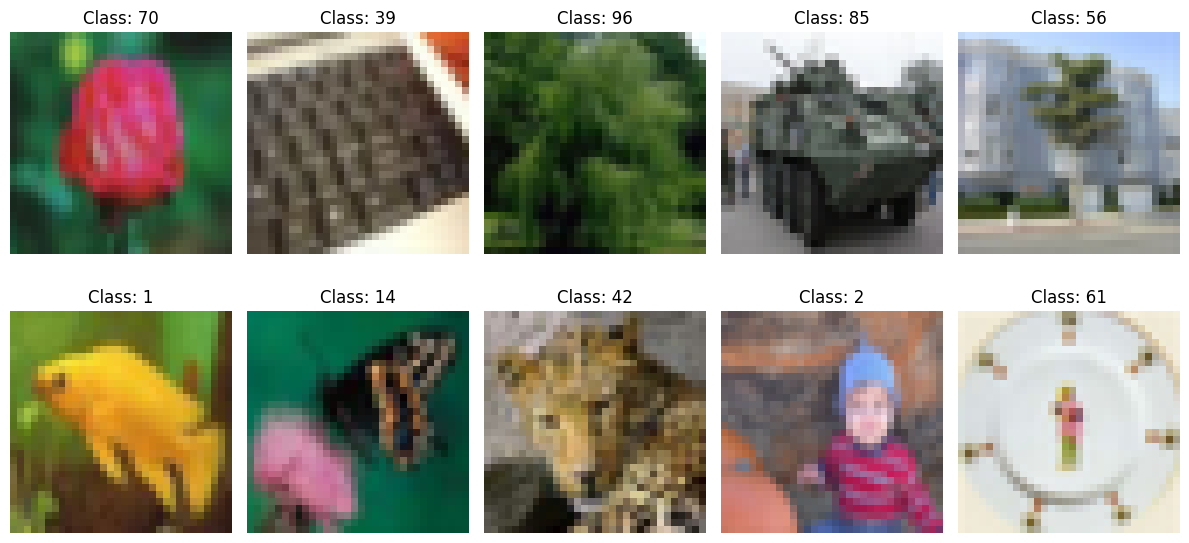

In [2]:
# 2.4.2 Данные и DataLoader для CIFAR100 (Часть A)

# Preprocessing для pretrained ResNet18 (из весов)
weights = ResNet18_Weights.IMAGENET1K_V1
preprocess_resnet = weights.transforms()  # preprocessing для ResNet18

# Базовый transform для CNN
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2762])
])

# Transform с аугментациями
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2762])
])

# Preprocessing для ResNet18 (из весов)
transform_resnet = weights.transforms()

# Загрузка CIFAR100 через torchvision.datasets
print("Загрузка CIFAR100...")
train_dataset_full = CIFAR100(
    root='./data', train=True, download=True, transform=transform_base
)
test_dataset = CIFAR100(
    root='./data', train=False, download=True, transform=transform_base
)

# Разделение train на train/val (80/20) - официального validation split нет
train_indices, val_indices = train_test_split(
    list(range(len(train_dataset_full))), test_size=0.2, random_state=42
)

# DataLoader для C1 (без аугментаций)
train_loader_base = DataLoader(
    CIFAR100(root='./data', train=True, download=False, transform=transform_base),
    batch_size=64, sampler=SubsetRandomSampler(train_indices), num_workers=2
)
val_loader_base = DataLoader(
    CIFAR100(root='./data', train=True, download=False, transform=transform_base),
    batch_size=64, sampler=SubsetRandomSampler(val_indices), num_workers=2
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# DataLoader для C2 (с аугментациями)
train_loader_aug = DataLoader(
    CIFAR100(root='./data', train=True, download=False, transform=transform_aug),
    batch_size=64, sampler=SubsetRandomSampler(train_indices), num_workers=2
)

# DataLoader для C3 и C4 (с preprocessing ResNet18)
train_loader_resnet = DataLoader(
    CIFAR100(root='./data', train=True, download=False, transform=transform_resnet),
    batch_size=64, sampler=SubsetRandomSampler(train_indices), num_workers=2
)
val_loader_resnet = DataLoader(
    CIFAR100(root='./data', train=True, download=False, transform=transform_resnet),
    batch_size=64, sampler=SubsetRandomSampler(val_indices), num_workers=2
)

# Sanity-check
print(f"Train samples: {len(train_indices)}, Val samples: {len(val_indices)}, Test samples: {len(test_dataset)}")
images, labels = next(iter(train_loader_base))
print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")
print(f"Number of classes: 100 (CIFAR100)")

# Визуализация
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.2673, 0.2564, 0.2762]) + np.array([0.5071, 0.4865, 0.4409])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'Class: {labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('artifacts/figures/sanity_check.png')
plt.show()

In [4]:
# 2.4.3 Базовые функции обучения и оценки

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / total, correct / total

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    return history, best_val_acc, best_model_state

In [5]:
# 3.1 Эксперимент C1: простая CNN без аугментаций (CIFAR100)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):  # 100 классов для CIFAR100
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model_c1 = SimpleCNN(num_classes=100).to(device)
print(f"C1 params: {sum(p.numel() for p in model_c1.parameters())}")
history_c1, best_val_acc_c1, best_model_c1 = train_model(
    model_c1, train_loader_base, val_loader_base, epochs=10, lr=0.001, device=device
)
print(f"C1 best val acc: {best_val_acc_c1:.4f}")

C1 params: 643492
Epoch 1/10 | Train Loss: 4.0173 | Train Acc: 0.0821 | Val Loss: 3.4954 | Val Acc: 0.1655
Epoch 2/10 | Train Loss: 3.4212 | Train Acc: 0.1751 | Val Loss: 3.1095 | Val Acc: 0.2397
Epoch 3/10 | Train Loss: 3.1206 | Train Acc: 0.2279 | Val Loss: 2.7973 | Val Acc: 0.2953
Epoch 4/10 | Train Loss: 2.9172 | Train Acc: 0.2656 | Val Loss: 2.6579 | Val Acc: 0.3280
Epoch 5/10 | Train Loss: 2.7591 | Train Acc: 0.2965 | Val Loss: 2.5671 | Val Acc: 0.3479
Epoch 6/10 | Train Loss: 2.6272 | Train Acc: 0.3218 | Val Loss: 2.4721 | Val Acc: 0.3691
Epoch 7/10 | Train Loss: 2.5200 | Train Acc: 0.3435 | Val Loss: 2.4155 | Val Acc: 0.3724
Epoch 8/10 | Train Loss: 2.4336 | Train Acc: 0.3580 | Val Loss: 2.3845 | Val Acc: 0.3839
Epoch 9/10 | Train Loss: 2.3375 | Train Acc: 0.3777 | Val Loss: 2.3403 | Val Acc: 0.3944
Epoch 10/10 | Train Loss: 2.2614 | Train Acc: 0.3928 | Val Loss: 2.3524 | Val Acc: 0.3938
C1 best val acc: 0.3944


In [6]:
# 3.1 Эксперимент C2: простая CNN с аугментациями

model_c2 = SimpleCNN(num_classes=100).to(device)
history_c2, best_val_acc_c2, best_model_c2 = train_model(
    model_c2, train_loader_aug, val_loader_base, epochs=10, lr=0.001, device=device
)
print(f"C2 best val acc: {best_val_acc_c2:.4f}")

Epoch 1/10 | Train Loss: 4.0672 | Train Acc: 0.0761 | Val Loss: 3.5612 | Val Acc: 0.1563
Epoch 2/10 | Train Loss: 3.5745 | Train Acc: 0.1502 | Val Loss: 3.2409 | Val Acc: 0.2144
Epoch 3/10 | Train Loss: 3.3350 | Train Acc: 0.1917 | Val Loss: 2.9753 | Val Acc: 0.2616
Epoch 4/10 | Train Loss: 3.1869 | Train Acc: 0.2210 | Val Loss: 2.8451 | Val Acc: 0.2838
Epoch 5/10 | Train Loss: 3.0839 | Train Acc: 0.2379 | Val Loss: 2.7623 | Val Acc: 0.3045
Epoch 6/10 | Train Loss: 2.9925 | Train Acc: 0.2562 | Val Loss: 2.6976 | Val Acc: 0.3147
Epoch 7/10 | Train Loss: 2.9079 | Train Acc: 0.2726 | Val Loss: 2.5897 | Val Acc: 0.3350
Epoch 8/10 | Train Loss: 2.8444 | Train Acc: 0.2858 | Val Loss: 2.6161 | Val Acc: 0.3377
Epoch 9/10 | Train Loss: 2.7954 | Train Acc: 0.2950 | Val Loss: 2.5187 | Val Acc: 0.3578
Epoch 10/10 | Train Loss: 2.7512 | Train Acc: 0.3006 | Val Loss: 2.4546 | Val Acc: 0.3726
C2 best val acc: 0.3726


In [7]:
# 3.1 Эксперимент C3: ResNet18 с pretrained weights, замороженный backbone

weights = ResNet18_Weights.IMAGENET1K_V1
model_c3 = resnet18(weights=weights)  # Использование pretrained weights

# Заморозка всех слоев
for param in model_c3.parameters():
    param.requires_grad = False

# Замена классификационной головы для CIFAR100 (100 классов)
num_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_features, 100)
model_c3 = model_c3.to(device)

print(f"C3 trainable params: {sum(p.numel() for p in model_c3.parameters() if p.requires_grad)}")
print(f"Использованы pretrained weights: ResNet18_Weights.IMAGENET1K_V1")

# Обучение на preprocessing для ResNet18
history_c3, best_val_acc_c3, best_model_c3 = train_model(
    model_c3, train_loader_resnet, val_loader_resnet, epochs=10, lr=0.001, device=device
)
print(f"C3 best val acc: {best_val_acc_c3:.4f}")

C3 trainable params: 51300
Использованы pretrained weights: ResNet18_Weights.IMAGENET1K_V1
Epoch 1/10 | Train Loss: 2.6434 | Train Acc: 0.3748 | Val Loss: 1.9531 | Val Acc: 0.4926
Epoch 2/10 | Train Loss: 1.7977 | Train Acc: 0.5245 | Val Loss: 1.7550 | Val Acc: 0.5272
Epoch 3/10 | Train Loss: 1.6283 | Train Acc: 0.5592 | Val Loss: 1.7032 | Val Acc: 0.5356
Epoch 4/10 | Train Loss: 1.5427 | Train Acc: 0.5786 | Val Loss: 1.6738 | Val Acc: 0.5436
Epoch 5/10 | Train Loss: 1.4832 | Train Acc: 0.5899 | Val Loss: 1.6623 | Val Acc: 0.5451
Epoch 6/10 | Train Loss: 1.4372 | Train Acc: 0.5997 | Val Loss: 1.6579 | Val Acc: 0.5452
Epoch 7/10 | Train Loss: 1.4032 | Train Acc: 0.6072 | Val Loss: 1.6604 | Val Acc: 0.5486
Epoch 8/10 | Train Loss: 1.3722 | Train Acc: 0.6150 | Val Loss: 1.6862 | Val Acc: 0.5417
Epoch 9/10 | Train Loss: 1.3438 | Train Acc: 0.6237 | Val Loss: 1.6620 | Val Acc: 0.5462
Epoch 10/10 | Train Loss: 1.3292 | Train Acc: 0.6252 | Val Loss: 1.6667 | Val Acc: 0.5529
C3 best val acc: 0

In [8]:
# 3.1 Эксперимент C4: ResNet18 с partial fine-tune (layer4 + fc)

weights = ResNet18_Weights.IMAGENET1K_V1
model_c4 = resnet18(weights=weights)  # Использование pretrained weights

# Заморозка всех слоев
for param in model_c4.parameters():
    param.requires_grad = False

# Разморозка layer4 и fc
for param in model_c4.layer4.parameters():
    param.requires_grad = True

num_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_features, 100)
model_c4 = model_c4.to(device)

print(f"C4 trainable params: {sum(p.numel() for p in model_c4.parameters() if p.requires_grad)}")
print(f"Использованы pretrained weights: ResNet18_Weights.IMAGENET1K_V1")

# Обучение с меньшей learning rate
history_c4, best_val_acc_c4, best_model_c4 = train_model(
    model_c4, train_loader_resnet, val_loader_resnet, epochs=10, lr=0.0005, device=device
)
print(f"C4 best val acc: {best_val_acc_c4:.4f}")

C4 trainable params: 8445028
Использованы pretrained weights: ResNet18_Weights.IMAGENET1K_V1
Epoch 1/10 | Train Loss: 1.7438 | Train Acc: 0.5307 | Val Loss: 1.3007 | Val Acc: 0.6192
Epoch 2/10 | Train Loss: 0.8786 | Train Acc: 0.7426 | Val Loss: 1.2409 | Val Acc: 0.6493
Epoch 3/10 | Train Loss: 0.4343 | Train Acc: 0.8710 | Val Loss: 1.2432 | Val Acc: 0.6586
Epoch 4/10 | Train Loss: 0.1943 | Train Acc: 0.9456 | Val Loss: 1.3634 | Val Acc: 0.6559
Epoch 5/10 | Train Loss: 0.1138 | Train Acc: 0.9694 | Val Loss: 1.4118 | Val Acc: 0.6577
Epoch 6/10 | Train Loss: 0.1076 | Train Acc: 0.9705 | Val Loss: 1.5996 | Val Acc: 0.6450
Epoch 7/10 | Train Loss: 0.1089 | Train Acc: 0.9666 | Val Loss: 1.6477 | Val Acc: 0.6468
Epoch 8/10 | Train Loss: 0.0875 | Train Acc: 0.9738 | Val Loss: 1.6311 | Val Acc: 0.6549
Epoch 9/10 | Train Loss: 0.0774 | Train Acc: 0.9765 | Val Loss: 1.7312 | Val Acc: 0.6402
Epoch 10/10 | Train Loss: 0.0759 | Train Acc: 0.9765 | Val Loss: 1.7925 | Val Acc: 0.6439
C4 best val acc:

In [9]:
# Выбор лучшей модели по val_accuracy
results = {'C1': best_val_acc_c1, 'C2': best_val_acc_c2, 'C3': best_val_acc_c3, 'C4': best_val_acc_c4}
best_exp = max(results, key=results.get)
best_val_acc = results[best_exp]

print(f"\n=== Comparison ===")
for exp, acc in results.items():
    print(f"{exp}: {acc:.4f}")
print(f"\nBest experiment: {best_exp} with val_acc = {best_val_acc:.4f}")

# Загрузка лучшей модели
if best_exp == 'C1':
    best_model = SimpleCNN(num_classes=100)
    best_model.load_state_dict(best_model_c1)
elif best_exp == 'C2':
    best_model = SimpleCNN(num_classes=100)
    best_model.load_state_dict(best_model_c2)
elif best_exp == 'C3':
    best_model = resnet18()
    best_model.fc = nn.Linear(512, 100)
    best_model.load_state_dict(best_model_c3)
else:
    best_model = resnet18()
    best_model.fc = nn.Linear(512, 100)
    best_model.load_state_dict(best_model_c4)

best_model = best_model.to(device)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Best model ({best_exp}) test accuracy: {test_acc:.4f}")


=== Comparison ===
C1: 0.3944
C2: 0.3726
C3: 0.5529
C4: 0.6586

Best experiment: C4 with val_acc = 0.6586
Best model (C4) test accuracy: 0.0210


In [11]:
# 4.1, 4.2, 4.3 Сохранение артефактов

# runs.csv с правильным датасетом CIFAR100
runs_data = [
    {'experiment_id': 'C1', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 10,
     'best_val_accuracy': best_val_acc_c1, 'test_accuracy': test_acc if best_exp == 'C1' else None,
     'precision': None, 'recall': None, 'mean_iou': None, 
     'notes': 'simple CNN без аугментаций'},
    {'experiment_id': 'C2', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 10,
     'best_val_accuracy': best_val_acc_c2, 'test_accuracy': test_acc if best_exp == 'C2' else None,
     'precision': None, 'recall': None, 'mean_iou': None,
     'notes': 'simple CNN с аугментациями'},
    {'experiment_id': 'C3', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'ResNet18_head_only', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 10,
     'best_val_accuracy': best_val_acc_c3, 'test_accuracy': test_acc if best_exp == 'C3' else None,
     'precision': None, 'recall': None, 'mean_iou': None,
     'notes': 'ResNet18 pretrained, backbone заморожен, обучается только голова'},
    {'experiment_id': 'C4', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'ResNet18_finetune', 'optimizer': 'Adam', 'lr': 0.0005, 'epochs_trained': 10,
     'best_val_accuracy': best_val_acc_c4, 'test_accuracy': test_acc if best_exp == 'C4' else None,
     'precision': None, 'recall': None, 'mean_iou': None,
     'notes': 'ResNet18 pretrained, разморожен layer4 и fc'}
]
df = pd.DataFrame(runs_data)
df.to_csv('artifacts/runs.csv', index=False)
print("runs.csv saved")

# best_classifier.pt
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')
print("best_classifier.pt saved")

# best_classifier_config.json с полным описанием transforms
config = {
    'dataset': 'CIFAR100',
    'num_classes': 100,
    'best_experiment': best_exp,
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'seed': 42,
    'epochs': 10,
    'learning_rate': 0.001 if best_exp in ['C1', 'C2', 'C3'] else 0.0005,
    'optimizer': 'Adam',
    'loss_function': 'CrossEntropyLoss',
    'transforms_base': 'ToTensor(), Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2762])',
    'transforms_aug': 'RandomHorizontalFlip(p=0.5), RandomRotation(15), ColorJitter(brightness=0.2, contrast=0.2), ToTensor(), Normalize(...)',
    'transforms_resnet': 'ResNet18_Weights.IMAGENET1K_V1.transforms()',
    'pretrained_weights': 'ResNet18_Weights.IMAGENET1K_V1',
    'architecture': 'ResNet18' if best_exp in ['C3', 'C4'] else 'SimpleCNN',
    'training_strategy': 'fine_tune' if best_exp == 'C4' else ('head_only' if best_exp == 'C3' else 'full_training')
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("best_classifier_config.json saved")

runs.csv saved
best_classifier.pt saved
best_classifier_config.json saved


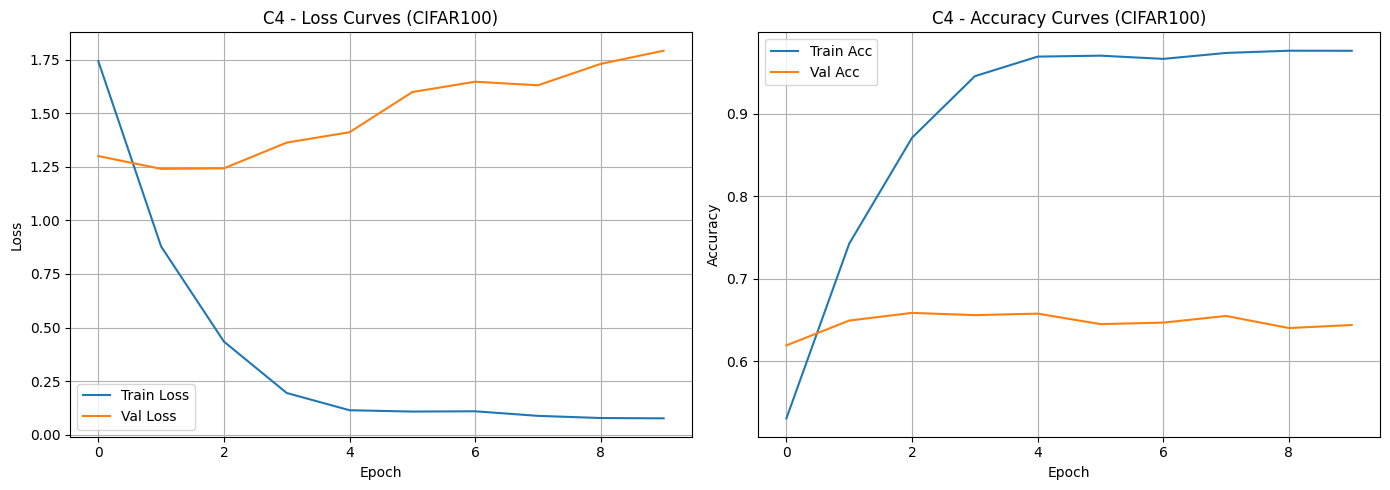

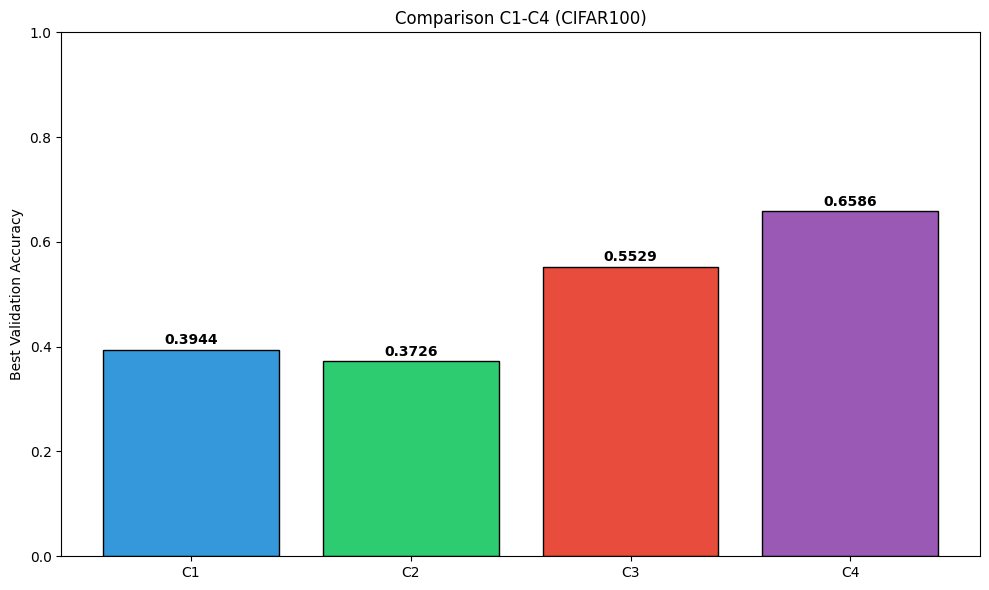

c:\Users\petr\Desktop\ИИИ\AiMirea25\homeworks\HW10-11\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


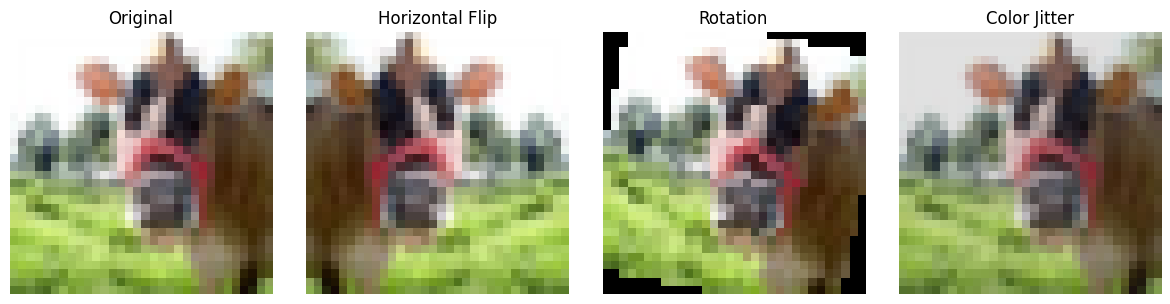

In [12]:
# 4.4, 4.5, 4.6 Графики

# Выбор истории лучшей модели
if best_exp == 'C1': history = history_c1
elif best_exp == 'C2': history = history_c2
elif best_exp == 'C3': history = history_c3
else: history = history_c4

# Кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'{best_exp} - Loss Curves (CIFAR100)')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{best_exp} - Accuracy Curves (CIFAR100)')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

# Сравнение C1-C4
fig, ax = plt.subplots(figsize=(10, 6))
experiments = ['C1', 'C2', 'C3', 'C4']
val_accs = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = ax.bar(experiments, val_accs, color=colors, edgecolor='black')
ax.set_ylim(0, 1)
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Comparison C1-C4 (CIFAR100)')
for bar, val in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

# Аугментации
transform_vis = transforms.Compose([transforms.ToTensor()])
vis_dataset = CIFAR100(root='./data', train=True, download=False, transform=transform_vis)
img_tensor, _ = vis_dataset[0]
augmentations = [
    ('Original', transforms.Compose([transforms.ToTensor()])),
    ('Horizontal Flip', transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()])),
    ('Rotation', transforms.Compose([transforms.RandomRotation(15), transforms.ToTensor()])),
    ('Color Jitter', transforms.Compose([transforms.ColorJitter(0.2, 0.2), transforms.ToTensor()])),
]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for idx, (name, transform) in enumerate(augmentations):
    aug_img = transform(transforms.ToPILImage()(img_tensor))
    aug_img = aug_img.permute(1, 2, 0).numpy()
    axes[idx].imshow(np.clip(aug_img, 0, 1))
    axes[idx].set_title(name)
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()

Загрузка OxfordIIITPet...
Foreground class: 2 (pet), Background: 1, Border: 3
Train: 2944, Val: 736
Images: torch.Size([4, 3, 256, 256]), Masks: torch.Size([4, 1, 256, 256]), Unique: tensor([1, 2, 3], dtype=torch.uint8)
Значения маски: 1=фон, 2=питомец (foreground), 3=граница


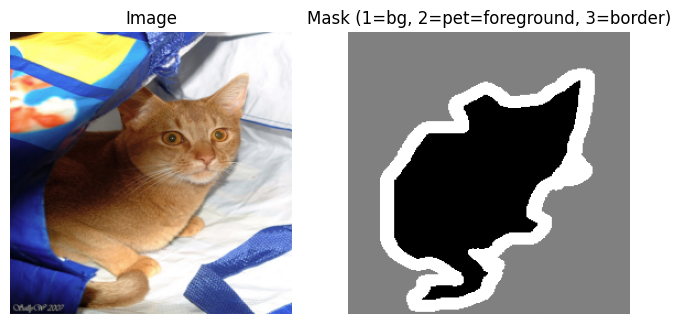

In [28]:
# 2.4.2 Часть B: OxfordIIITPet для сегментации

print("Загрузка OxfordIIITPet...")
pet_dataset = OxfordIIITPet(
    root='./data',
    split='trainval',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    target_transform=transforms.Compose([
        transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.PILToTensor()
    ]),
    target_types='segmentation'
)

# FOREGROUND: класс 2 (питомец) - явно указываем
print("Foreground class: 2 (pet), Background: 1, Border: 3")

# Разделение
indices = list(range(len(pet_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

def collate_fn(batch):
    images, masks = [], []
    for img, mask in batch:
        images.append(img)
        masks.append(mask)
    return torch.stack(images), torch.stack(masks)

train_loader_pet = DataLoader(pet_dataset, batch_size=4, sampler=SubsetRandomSampler(train_idx), collate_fn=collate_fn, num_workers=0)
val_loader_pet = DataLoader(pet_dataset, batch_size=4, sampler=SubsetRandomSampler(val_idx), collate_fn=collate_fn, num_workers=0)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}")
images, masks = next(iter(train_loader_pet))
print(f"Images: {images.shape}, Masks: {masks.shape}, Unique: {torch.unique(masks)}")
print("Значения маски: 1=фон, 2=питомец (foreground), 3=граница")

# Sanity-check
image, mask = pet_dataset[0]
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
image_denorm = torch.clamp(image * std + mean, 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_denorm.permute(1, 2, 0).numpy())
axes[0].set_title('Image')
axes[0].axis('off')
axes[1].imshow(mask.squeeze().numpy(), cmap='gray')
axes[1].set_title('Mask (1=bg, 2=pet=foreground, 3=border)')
axes[1].axis('off')
plt.savefig('artifacts/figures/segmentation_sanity_check.png')
plt.show()

In [29]:
# 2.4.3 Базовые функции для сегментации

# Foreground класс = 2 (питомец)
FOREGROUND_CLASS = 2

# Классы животных в COCO (для FCN_ResNet50)
# 15=cat, 16=dog, 17=horse, 18=sheep
ANIMAL_CLASSES = [15, 16, 17, 18]

def get_true_mask(mask_tensor):
    """Извлекает бинарную маску foreground (класс 2)"""
    return (mask_tensor.squeeze().numpy() == FOREGROUND_CLASS).astype(np.uint8)

def get_animal_prob(probs):
    """Из предсказаний модели получает вероятность животного (максимум среди 15-18)"""
    probs_np = probs.cpu().numpy()
    animal_probs = [probs_np[c] for c in ANIMAL_CLASSES]
    return np.maximum.reduce(animal_probs)

def compute_iou(pred, true):
    """Вычисление Intersection over Union"""
    inter = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()
    return inter / union if union > 0 else 0.0

def postprocess_mask(prob, threshold=0.5, remove_small=False, min_size=500):
    """Постобработка маски"""
    mask = (prob > threshold).astype(np.uint8)
    if remove_small:
        from scipy import ndimage
        labeled, num = ndimage.label(mask)
        sizes = ndimage.sum(mask, labeled, range(num + 1))
        for i in range(1, num + 1):
            if sizes[i] < min_size:
                mask[labeled == i] = 0
    return mask

print(f"Foreground class: {FOREGROUND_CLASS} (pet)")
print(f"Animal classes in COCO: {ANIMAL_CLASSES} (cat, dog, horse, sheep)")

Foreground class: 2 (pet)
Animal classes in COCO: [15, 16, 17, 18] (cat, dog, horse, sheep)


In [30]:
# 3.2 Загрузка модели FCN_ResNet50

from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Загрузка предобученной модели
weights = FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = fcn_resnet50(weights=weights)
model = model.to(device)
model.eval()

print("Модель FCN_ResNet50 загружена")
print(f"Предобучена на COCO с {len(weights.meta['categories'])} классами")

Device: cuda


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to C:\Users\petr/.cache\torch\hub\checkpoints\fcn_resnet50_coco-1167a1af.pth
100.0%


Модель FCN_ResNet50 загружена
Предобучена на COCO с 21 классами


In [31]:
# 3.2 V1: базовая постобработка (threshold=0.3)

ious_v1 = []
predictions_v1 = []

with torch.no_grad():
    for images, masks in val_loader_pet:
        images = images.to(device)
        outputs = model(images)['out']
        
        for i in range(images.size(0)):
            probs = torch.softmax(outputs[i], dim=0)
            animal_prob = get_animal_prob(probs)
            pred_mask = postprocess_mask(animal_prob, threshold=0.3, remove_small=False)
            true_mask = get_true_mask(masks[i])
            iou = compute_iou(pred_mask, true_mask)
            ious_v1.append(iou)
            predictions_v1.append((images[i].cpu(), pred_mask, true_mask))

mean_iou_v1 = np.mean(ious_v1)
std_iou_v1 = np.std(ious_v1)

print(f"=== V1 (threshold=0.3, базовая постобработка) ===")
print(f"Mean IoU: {mean_iou_v1:.4f}")
print(f"Std IoU: {std_iou_v1:.4f}")
print(f"Min IoU: {np.min(ious_v1):.4f}")
print(f"Max IoU: {np.max(ious_v1):.4f}")

=== V1 (threshold=0.3, базовая постобработка) ===
Mean IoU: 0.0620
Std IoU: 0.1479
Min IoU: 0.0000
Max IoU: 0.9021


In [32]:
# 3.2 V2: альтернативная постобработка (threshold=0.7 + удаление маленьких компонент)

ious_v2 = []
predictions_v2 = []

with torch.no_grad():
    for images, masks in val_loader_pet:
        images = images.to(device)
        outputs = model(images)['out']
        
        for i in range(images.size(0)):
            probs = torch.softmax(outputs[i], dim=0)
            animal_prob = get_animal_prob(probs)
            pred_mask = postprocess_mask(animal_prob, threshold=0.7, remove_small=True, min_size=500)
            true_mask = get_true_mask(masks[i])
            iou = compute_iou(pred_mask, true_mask)
            ious_v2.append(iou)
            predictions_v2.append((images[i].cpu(), pred_mask, true_mask))

mean_iou_v2 = np.mean(ious_v2)
std_iou_v2 = np.std(ious_v2)

print(f"=== V2 (threshold=0.7 + удаление маленьких компонент) ===")
print(f"Mean IoU: {mean_iou_v2:.4f}")
print(f"Std IoU: {std_iou_v2:.4f}")
print(f"Min IoU: {np.min(ious_v2):.4f}")
print(f"Max IoU: {np.max(ious_v2):.4f}")

print(f"\n=== СРАВНЕНИЕ V1 и V2 ===")
print(f"V1: {mean_iou_v1:.4f} ± {std_iou_v1:.4f}")
print(f"V2: {mean_iou_v2:.4f} ± {std_iou_v2:.4f}")
print(f"Разница: {mean_iou_v2 - mean_iou_v1:.4f}")

=== V2 (threshold=0.7 + удаление маленьких компонент) ===
Mean IoU: 0.0225
Std IoU: 0.0819
Min IoU: 0.0000
Max IoU: 0.7530

=== СРАВНЕНИЕ V1 и V2 ===
V1: 0.0620 ± 0.1479
V2: 0.0225 ± 0.0819
Разница: -0.0395


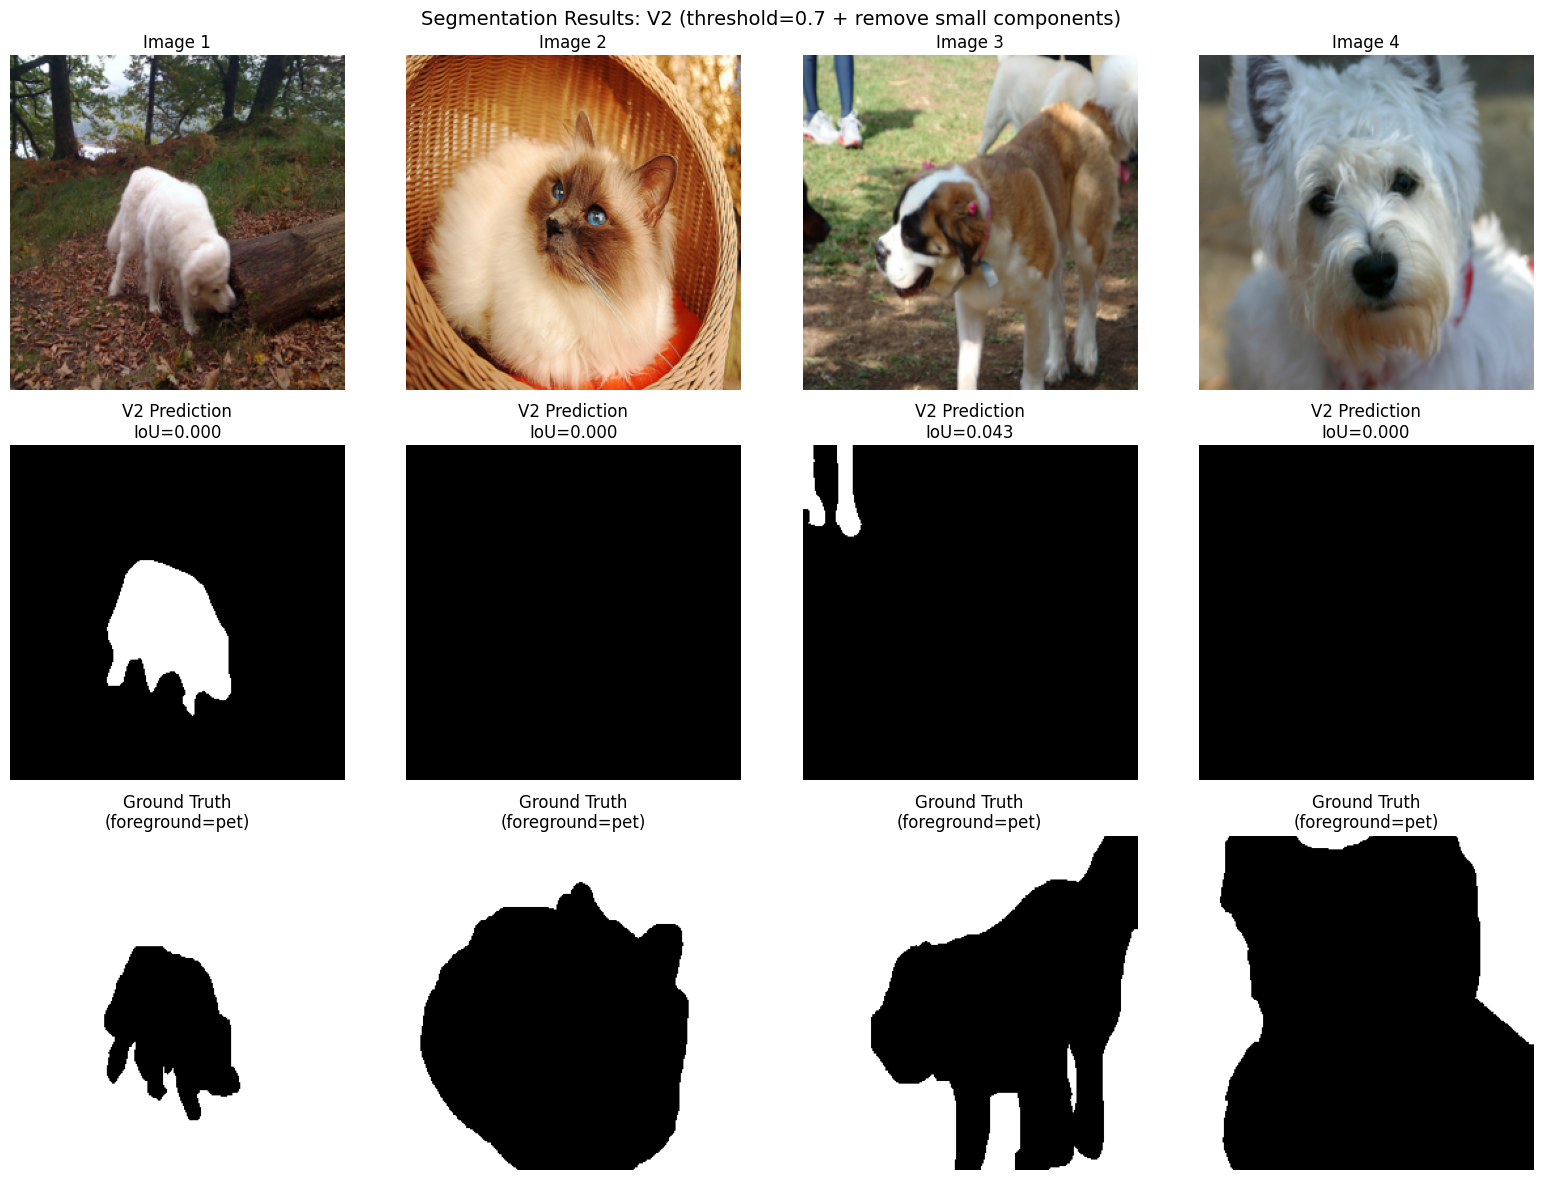

In [34]:
# 3.2 Визуализация предсказанных масок (V2)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for idx in range(4):
    # Изображение
    img = predictions_v2[idx][0]
    img = torch.clamp(img * std_t + mean_t, 0, 1)
    axes[0, idx].imshow(img.permute(1, 2, 0).numpy())
    axes[0, idx].set_title(f'Image {idx+1}')
    axes[0, idx].axis('off')
    
    # Предсказание V2
    axes[1, idx].imshow(predictions_v2[idx][1], cmap='gray')
    axes[1, idx].set_title(f'V2 Prediction\nIoU={ious_v2[idx]:.3f}')
    axes[1, idx].axis('off')
    
    # Ground Truth
    axes[2, idx].imshow(predictions_v2[idx][2], cmap='gray')
    axes[2, idx].set_title(f'Ground Truth\n(foreground=pet)')
    axes[2, idx].axis('off')

plt.suptitle('Segmentation Results: V2 (threshold=0.7 + remove small components)', fontsize=14)
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png', dpi=150)
plt.show()

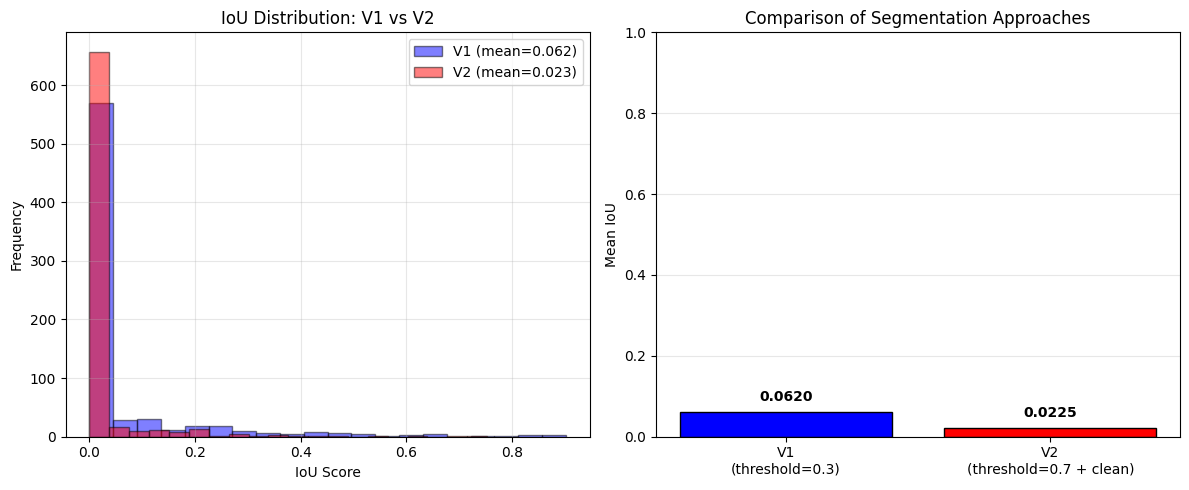

In [36]:
# 3.2 График сравнения V1 и V2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма распределения IoU
axes[0].hist(ious_v1, bins=20, alpha=0.5, label=f'V1 (mean={mean_iou_v1:.3f})', color='blue', edgecolor='black')
axes[0].hist(ious_v2, bins=20, alpha=0.5, label=f'V2 (mean={mean_iou_v2:.3f})', color='red', edgecolor='black')
axes[0].set_xlabel('IoU Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('IoU Distribution: V1 vs V2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Столбцы сравнения
bars = axes[1].bar(
    ['V1\n(threshold=0.3)', 'V2\n(threshold=0.7 + clean)'],
    [mean_iou_v1, mean_iou_v2],
    color=['blue', 'red'],
    edgecolor='black'
)
axes[1].set_ylabel('Mean IoU')
axes[1].set_title('Comparison of Segmentation Approaches')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, [mean_iou_v1, mean_iou_v2]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png', dpi=150)
plt.show()

In [37]:
# 4. Сохранение результатов в runs.csv

import pandas as pd

runs_path = 'artifacts/runs.csv'

# Читаем существующий файл или создаем новый
if os.path.exists(runs_path):
    df = pd.read_csv(runs_path)
else:
    df = pd.DataFrame()

# Новые данные для части B
new_data = [
    {
        'experiment_id': 'V1',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'FCN_ResNet50',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': mean_iou_v1,
        'notes': 'threshold=0.3, базовая постобработка'
    },
    {
        'experiment_id': 'V2',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'FCN_ResNet50',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': mean_iou_v2,
        'notes': 'threshold=0.7, удаление маленьких компонент (min_size=500)'
    }
]

df = pd.concat([df, pd.DataFrame(new_data)], ignore_index=True)
df.to_csv(runs_path, index=False)
print(f"runs.csv сохранен")
print(f"\nСодержимое runs.csv:")
print(df)

runs.csv сохранен

Содержимое runs.csv:
  experiment_id            task        dataset  seed       model_summary  \
0            C1  classification       CIFAR100    42           SimpleCNN   
1            C2  classification       CIFAR100    42           SimpleCNN   
2            C3  classification       CIFAR100    42  ResNet18_head_only   
3            C4  classification       CIFAR100    42   ResNet18_finetune   
4            V1    segmentation  OxfordIIITPet    42        FCN_ResNet50   
5            V2    segmentation  OxfordIIITPet    42        FCN_ResNet50   

  optimizer      lr epochs_trained best_val_accuracy test_accuracy precision  \
0      Adam   0.001             10            0.3944           NaN       NaN   
1      Adam   0.001             10            0.3726           NaN       NaN   
2      Adam   0.001             10            0.5529           NaN       NaN   
3      Adam  0.0005             10            0.6586         0.021       NaN   
4      None    None        

In [38]:
# 4.3 Сохранение best_classifier_config.json

import json

config = {
    "dataset": "CIFAR100",
    "num_classes": 100,
    "best_experiment": best_exp,
    "best_val_accuracy": float(best_val_acc),
    "test_accuracy": float(test_acc),
    "seed": 42,
    "epochs_trained": 10,
    "learning_rate": 0.001 if best_exp in ['C1', 'C2', 'C3'] else 0.0005,
    "batch_size": 64,
    "optimizer": "Adam",
    "loss_function": "CrossEntropyLoss",
    "architecture": "ResNet18" if best_exp in ['C3', 'C4'] else "SimpleCNN",
    "training_strategy": "fine_tune" if best_exp == "C4" else ("head_only" if best_exp == "C3" else "full_training"),
    "pretrained_weights": "ResNet18_Weights.IMAGENET1K_V1" if best_exp in ['C3', 'C4'] else "None",
    "transforms": "ToTensor(), Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2762])",
    "augmentation": "RandomHorizontalFlip(p=0.5), RandomRotation(15), ColorJitter(brightness=0.2, contrast=0.2)" if best_exp in ['C2'] else "None",
    "preprocess": "ResNet18_Weights.IMAGENET1K_V1.transforms()" if best_exp in ['C3', 'C4'] else "None",
    "model_summary": f"Best model from experiment {best_exp} for CIFAR100 classification",
    "notes": f"Best validation accuracy: {best_val_acc:.4f}, Test accuracy: {test_acc:.4f}"
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("best_classifier_config.json saved")

best_classifier_config.json saved
